In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
df = pd.read_csv("data.csv")

x = df[["RAM_GB", "GPU_Score", "CPU_GHz", "Storage_GB"]].values
y = df["FPS"].values

In [5]:
w = np.zeros(4)
b = 0

print(w.shape)
print(w)

(4,)
[0. 0. 0. 0.]


In [6]:
def predict(w, x, b):

    y_pred = np.dot(x, w) + b

    return y_pred

In [9]:
print(predict(w, np.array([[12, 4200, 2.5, 320]]), b))

[0.]


In [10]:
def compute_cost(w, x, b, y):

    m = len(x)

    y_pred = predict(w, x, b)

    cost = (1/(2*m)) * np.sum((y_pred - y)**2)

    return cost

In [11]:
print(compute_cost(w, x, b, y))

2731.025


In [12]:
def compute_gradient(w, x, b, y):

    m = len(x)

    y_pred = predict(w, x, b)

    error = y_pred - y

    dj_dw = (1/m) * np.dot(error, x)

    dj_db = (1/m) * np.sum(error)

    return dj_dw, dj_db

In [13]:
alpha = 0.00000001
iterations = 10000

cost_history = []
predicted_fps = []

for _ in range(iterations):

    dj_dw, dj_db = compute_gradient(w, x, b, y)

    w = w - (alpha * dj_dw)
    b = b - (alpha * dj_db)

    cost = compute_cost(w, x, b, y)

    cost_history.append(cost)

    fps = predict(w, np.array([[12, 4200, 2.5, 320]]), b)

    predicted_fps.append(fps)

In [14]:
print(f"Final w: {w}")
print(f"Final b: {b}")

Final w: [ 3.77125145e-04  1.21832098e-02 -9.30587455e-06  1.07747513e-02]
Final b: -1.3841402359629062e-05


In [15]:
fps = predict(w, np.array([[12, 4200, 2.5, 320]]), b).item()

print(f"Predicted FPS: {fps:.2f}")

Predicted FPS: 54.62


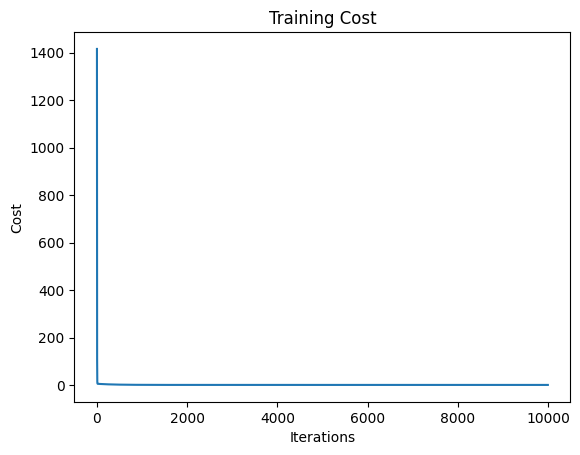

In [16]:
plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.title("Training Cost")

plt.show()

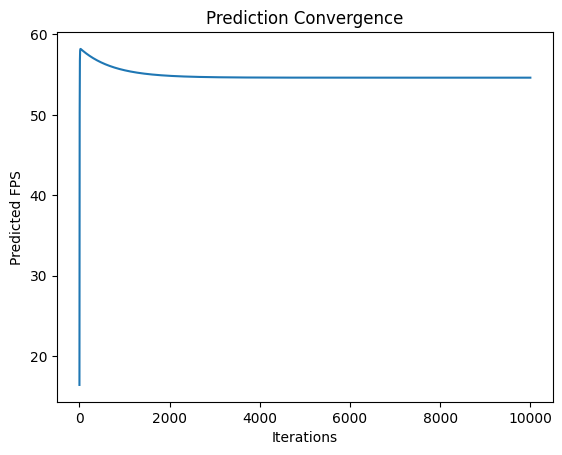

In [17]:
plt.plot(predicted_fps)

plt.xlabel("Iterations")
plt.ylabel("Predicted FPS")

plt.title("Prediction Convergence")

plt.show()

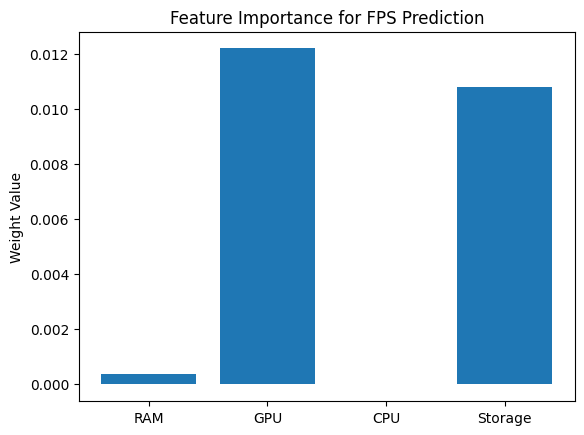

In [18]:
features = ["RAM", "GPU", "CPU", "Storage"]

plt.bar(features, w)

plt.title("Feature Importance for FPS Prediction")

plt.ylabel("Weight Value")

plt.show()